<a href="https://colab.research.google.com/github/laiimour/cqv-hac-mopso/blob/main/05_Compara%C3%A7%C3%A3o_Fixo_Adaptativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane
!pip install pennylane-qiskit
!pip install pennylane-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 749.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 583.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 

In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import random
import math
import scipy.stats

np.random.seed(42)
random.seed(42)

# 1. Carregamento Multiclasse
iris = load_iris()
X = iris.data.astype(float)
Y = iris.target

def one_hot(labels, num_classes=4):
    oh = np.zeros((len(labels), num_classes))
    oh[np.arange(len(labels)), labels] = 1.0
    return oh

Y_oh = one_hot(Y)

# 2. Pré-processamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Normalização L2
norm = np.sqrt(np.sum(X_pca**2, axis=-1, keepdims=True))
X_norm = X_pca / norm

# Pad para o modelo avançado (o modelo básico usará apenas a primeira metade)
X_pad = np.hstack((X_norm, X_norm))

# 3. Divisão de Treino e Teste
X_treino_pad, X_teste_pad, Y_treino, Y_teste, Y_treino_oh, Y_teste_oh = train_test_split(
    X_pad, Y, Y_oh, test_size=0.20, random_state=42, stratify=Y
)

# Dados específicos para o modelo básico (apenas 4 features)
X_treino_basico = X_treino_pad[:, :4]
X_teste_basico = X_teste_pad[:, :4]

def custo_cce(probs, y_batch_oh):
    """Entropia Cruzada Categórica para 3+ classes"""
    probs = np.clip(probs, 1e-10, 1.0)
    return -np.mean(np.sum(y_batch_oh * np.log(probs), axis=1))

# Armazenar históricos para o gráfico final
hist_acc_basico = []
hist_acc_avancado = []

In [7]:
print("\n--- TREINANDO MODELO BÁSICO (Ansatz Fixo + Softmax) ---")

def softmax(logits):
    """Função rigorosa para converter saídas em probabilidades multiclasse"""
    e_x = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

num_qubits_basico = 2
dev_basico = qml.device("default.qubit", wires=num_qubits_basico)

def layer_basica(layer_weights):
    for wire in range(num_qubits_basico):
        qml.Rot(*layer_weights[wire], wires=wire)
    qml.CNOT(wires=[0, 1])

@qml.qnode(dev_basico)
def circ_basico(weights, x):
    qml.AmplitudeEmbedding(x, wires=range(num_qubits_basico), normalize=True)
    for layer_weights in weights:
        layer_basica(layer_weights)
    return qml.probs(wires=[0, 1])

# A Função de custo agora otimiza os Pesos Quânticos (p) e o Viés Clássico (b)
def treino_basico(p, b, x_batch, y_batch_oh):
    saida_quantica = np.array([circ_basico(p, x) for x in x_batch])
    logits = saida_quantica + b # Adição do bias
    probs = softmax(logits)     # Softmax

    probs = np.clip(probs, 1e-10, 1.0)
    return -np.mean(np.sum(y_batch_oh * np.log(probs), axis=1))

# Inicialização conjunta (Pesos e Bias)
num_layers = 6
pesos_basicos = 0.05 * np.random.randn(num_layers, num_qubits_basico, 3, requires_grad=True)
bias_basico = np.zeros(4, requires_grad=True)

opt_basico = qml.AdamOptimizer(stepsize=0.05)
hist_acc_basico = []

for it in range(150): # Aumentado ligeiramente para garantir convergência
    # O otimizador atualiza ambos os parâmetros simultaneamente
    pesos_basicos, bias_basico = opt_basico.step(treino_basico, pesos_basicos, bias_basico, x_batch=X_treino_basico, y_batch_oh=Y_treino_oh)

    if (it + 1) % 10 == 0:
        saida_q = np.array([circ_basico(pesos_basicos, x) for x in X_treino_basico])
        probs = softmax(saida_q + bias_basico)
        prev = np.argmax(probs, axis=1)
        acc = np.sum(Y_treino == prev) / len(Y_treino)
        hist_acc_basico.append(acc)
        print(f"Iteração Básico {it + 1:3d} | Acurácia: {acc * 100:.1f}%")


--- TREINANDO MODELO BÁSICO (Ansatz Fixo + Softmax) ---
Iteração Básico  10 | Acurácia: 60.8%
Iteração Básico  20 | Acurácia: 61.7%
Iteração Básico  30 | Acurácia: 61.7%
Iteração Básico  40 | Acurácia: 63.3%
Iteração Básico  50 | Acurácia: 63.3%
Iteração Básico  60 | Acurácia: 62.5%
Iteração Básico  70 | Acurácia: 63.3%
Iteração Básico  80 | Acurácia: 63.3%
Iteração Básico  90 | Acurácia: 63.3%
Iteração Básico 100 | Acurácia: 63.3%
Iteração Básico 110 | Acurácia: 63.3%
Iteração Básico 120 | Acurácia: 63.3%
Iteração Básico 130 | Acurácia: 63.3%
Iteração Básico 140 | Acurácia: 63.3%
Iteração Básico 150 | Acurácia: 63.3%


In [8]:
print("\n--- TREINANDO MODELO AVANÇADO (MOPSO + End-to-End + Softmax) ---")

def particionar(x): return x[:4], x[4:]

def aplicar_porta(porta, controle, alvo, peso):
    if porta == 'CRX': qml.CRX(peso, wires=[controle, alvo])
    elif porta == 'CRY': qml.CRY(peso, wires=[controle, alvo])
    elif porta == 'CRZ': qml.CRZ(peso, wires=[controle, alvo])
    elif porta == 'CX': qml.CNOT(wires=[controle, alvo])
    elif porta == 'CY': qml.CY(wires=[controle, alvo])
    elif porta == 'CZ': qml.CZ(wires=[controle, alvo])
    elif porta == 'RX': qml.RX(peso, wires=alvo)
    elif porta == 'RY': qml.RY(peso, wires=alvo)
    elif porta == 'RZ': qml.RZ(peso, wires=alvo)

def ansatz_circ(pesos, qubits):
    for i, q in enumerate(qubits): qml.RY(pesos[i], wires=q)
    for i in range(len(qubits)): qml.CRZ(pesos[len(qubits)+i], wires=[qubits[i], qubits[(i+1)%len(qubits)]])

# NOVA VERSÃO: Permite múltiplas camadas no bloco interativo para aumentar a expressividade
def ansatz_int_multicamadas(pesos, qubits, portas, num_layers):
    idx = 0
    for l in range(num_layers):
        for q in qubits:
            qml.RY(pesos[idx], wires=q); idx += 1
        m = len(qubits)
        for i in range(m):
            if portas[i] in ['CRX', 'CRY', 'CRZ', 'RX', 'RY', 'RZ']:
                aplicar_porta(portas[i], qubits[i], qubits[(i+1)%m], pesos[idx]); idx += 1
            else:
                aplicar_porta(portas[i], qubits[i], qubits[(i+1)%m], 0)

dev_g = qml.device("default.qubit", wires=8)
qubits_raiz = [0, 2, 6, 7]
config_mopso = ['RY', 'RY', 'CRX', 'RY']

# O bloco interativo tem 8 pesos por camada. Com 3 camadas, são 24 pesos interativos.
# Mais 8 pesos para a esquerda e 8 para a direita = 40 pesos totais.
pesos_totais = np.random.randn(40, requires_grad=True) * 0.1
bias_avancado = np.zeros(4, requires_grad=True)

@qml.qnode(dev_g)
def circ_g_unificado(pesos, x):
    x1, x2 = particionar(x)
    qml.AngleEmbedding(features=x1, wires=[0,1,2,3], rotation='Y')
    qml.AngleEmbedding(features=x2, wires=[4,5,6,7], rotation='Y')

    p_esq = pesos[:8]
    p_dir = pesos[8:16]
    p_int = pesos[16:]

    ansatz_circ(p_esq, [0,1,2,3])
    ansatz_circ(p_dir, [4,5,6,7])

    # Executa a arquitetura MOPSO com 3 repetições de profundidade
    ansatz_int_multicamadas(p_int, qubits_raiz, config_mopso, num_layers=3)

    return qml.probs(wires=qubits_raiz[:2])

def treino_avancado_unificado(p, b, x_batch, y_batch_oh):
    saida_quantica = np.array([circ_g_unificado(p, x) for x in x_batch])
    logits = saida_quantica + b
    probs = softmax(logits)

    probs = np.clip(probs, 1e-10, 1.0)
    return -np.mean(np.sum(y_batch_oh * np.log(probs), axis=1))

opt_avancado = qml.AdamOptimizer(stepsize=0.03) # Ajustado para a nova profundidade
hist_acc_avancado = []

for it in range(150):
    pesos_totais, bias_avancado = opt_avancado.step(treino_avancado_unificado, pesos_totais, bias_avancado, x_batch=X_treino_pad, y_batch_oh=Y_treino_oh)

    if (it + 1) % 10 == 0:
        saida_q = np.array([circ_g_unificado(pesos_totais, x) for x in X_treino_pad])
        probs = softmax(saida_q + bias_avancado)
        prev = np.argmax(probs, axis=1)
        acc = np.sum(Y_treino == prev) / len(Y_treino)
        hist_acc_avancado.append(acc)
        print(f"Iteração Avançado {it + 1:3d} | Acurácia: {acc * 100:.1f}%")


--- TREINANDO MODELO AVANÇADO (MOPSO + End-to-End + Softmax) ---
Iteração Avançado  10 | Acurácia: 66.7%
Iteração Avançado  20 | Acurácia: 66.7%
Iteração Avançado  30 | Acurácia: 78.3%
Iteração Avançado  40 | Acurácia: 74.2%
Iteração Avançado  50 | Acurácia: 73.3%
Iteração Avançado  60 | Acurácia: 69.2%
Iteração Avançado  70 | Acurácia: 70.0%
Iteração Avançado  80 | Acurácia: 71.7%
Iteração Avançado  90 | Acurácia: 70.8%
Iteração Avançado 100 | Acurácia: 70.8%
Iteração Avançado 110 | Acurácia: 70.0%
Iteração Avançado 120 | Acurácia: 70.8%
Iteração Avançado 130 | Acurácia: 70.8%
Iteração Avançado 140 | Acurácia: 70.8%
Iteração Avançado 150 | Acurácia: 70.8%


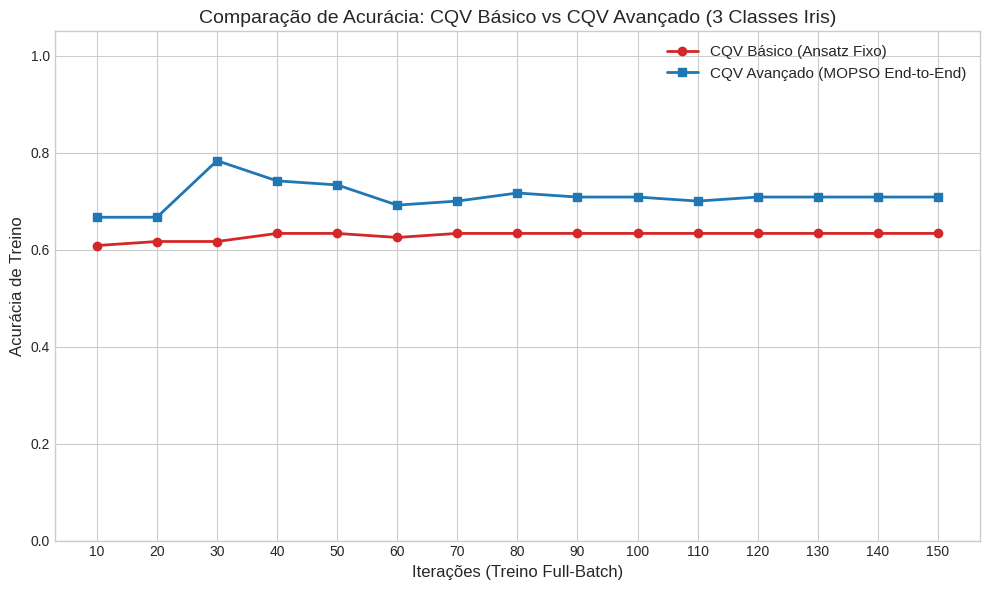

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 6))

# Cria o eixo x dinamicamente com base no tamanho real do histórico gravado
iteracoes = range(10, (len(hist_acc_avancado) + 1) * 10, 10)

plt.plot(iteracoes, hist_acc_basico[:len(iteracoes)], marker='o', linestyle='-', color='#d62728', label='CQV Básico (Ansatz Fixo)', linewidth=2)
plt.plot(iteracoes, hist_acc_avancado, marker='s', linestyle='-', color='#1f77b4', label='CQV Avançado (MOPSO End-to-End)', linewidth=2)

plt.title("Comparação de Acurácia: CQV Básico vs CQV Avançado (3 Classes Iris)", fontsize=14)
plt.xlabel("Iterações (Treino Full-Batch)", fontsize=12)
plt.ylabel("Acurácia de Treino", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(iteracoes)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()